https://github.com/cfrancois370/IMDB-Top-250-Analysis

#Project 1: Data Analysis Report

The Data source I am using is called the IMDb Top 250 Movies Dataset. This dataset has 250 rated movies on IMDB as of 2021, created from the IMDB website. The dataset has 250 rows and 13 columns. The columns are listed as Rank, Name(Title), Release Year, Rating, Genre, Certificate, Runtime, Budget, Box Office Revenue, Cast, Directors, and Writers.

Database Link: https://www.kaggle.com/datasets/rajugc/imdb-top-250-movies-dataset


Main Question: How does the release year, runtime, and content rating relate to the IMDB ratings of the top 250 films?

Sub 1: Has the average IMDB rating of Top 250 films changed over the decades? (1920s - 2020s)
Sub 2: Do different content ratings have significantly different average IMDB ratings?
Sub 3: Is there a relationship between movie runtime and ratings (IMDB)?


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Top250Movies_Cleaned.csv') # this is to load the dataset


cols = df.columns
print(df.columns.tolist())
print(df['run_time'].head())
print(df.dtypes)

['rank', 'name', 'year', 'rating', 'genre', 'certificate', 'run_time', 'decade', 'runtime_bin']
0    142
1    175
2    152
3    202
4     96
Name: run_time, dtype: int64
rank             int64
name            object
year             int64
rating         float64
genre           object
certificate     object
run_time         int64
decade           int64
runtime_bin     object
dtype: object


In [32]:
#This starts to change/keep the rating values
rating_map = {
    'G': 'G',
    'PG': 'PG',
    'PG-13': 'PG-13',
    'R': 'R',
    'NC-17': 'NC-17',

    # This is to change all the uneccessary rated ones:
    'Not Rated': 'Not Rated',
    'TV-MA': 'R',
    'TV-13': 'PG-13',
    'TV-PG': 'PG',
    'GP': 'PG',
    'X': 'NC-17',
    '18+': 'R',
    '13+': 'PG-13',
    'Unrated': 'Not Rated',
    'Approved': 'Not Rated',
    'Passed': 'Not Rated',
    'Not Available': 'Not Rated'
}

df['certificate'] = df['certificate'].map(rating_map)

print("Unique certificate values after mapping:")
print(df['certificate'].unique())
print(df['certificate'].value_counts())



Unique certificate values after mapping:
['R' 'PG-13' 'Not Rated' 'PG' 'G' 'NC-17']
certificate
R            99
Not Rated    56
PG           39
PG-13        36
G            19
NC-17         1
Name: count, dtype: int64


In [34]:
def converttom(s): # Here we will convert the hours of the movie duration to minutes.
  s = str(s).lower().replace(' ', '')
  hours = 0
  minutes = 0
  if 'h' in s:
    hours = int(s.split('h')[0])
    s = s.split('h')[1]
  if 'm' in s:
    minutes = int(s.replace('m', ''))
  return hours * 60 + minutes

df['run_time'] = df['run_time'].apply(converttom)

print(df['run_time'])






0      0
1      0
2      0
3      0
4      0
      ..
245    0
246    0
247    0
248    0
249    0
Name: run_time, Length: 250, dtype: int64


In [18]:
df.loc[df['name'] == 'The Boat', 'run_time'] = 25 # The movie "The Boat" doesnt seem to have a runtime so one gets added to make the project run smooth.

In [31]:
df.to_csv('Top250Movies_Cleaned.csv', index=False)
print("Saved")

Saved


In [ ]:
# Check for missing values (This code is here for the instructions of the project, I had to install a
# a clean version csv because everytime it reloaded, it would erase and mess up my code and cleaning.
# There is no need to run it because there is already a clean version of it.)
print("Missing values per column:")
display(df.isnull().sum())

if df.isnull().sum().sum() == 0:
    print("\nNo missing values found in the DataFrame.")
else:
    print("\nMissing values found. Further action might be needed (e.g., fillna, dropna).")

Missing values per column:


,0
rank,0
name,0
year,0
rating,0
genre,0
certificate,0
run_time,0



No missing values found in the DataFrame.


In [14]:
# Check for duplicate rows
num_duplicates = df.duplicated().sum()

if num_duplicates > 0:
    print(f"Found {num_duplicates} duplicate rows.")
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [20]:
numerical_cols = ['rank', 'year', 'rating', 'run_time']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 'outliers' DataFrame contains the rows where the current column's value
    # falls outside the calculated lower and upper bounds (IQR method).
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][[col, 'name']]

    print(f"\n--- Outliers in '{col}' ---")
    if not outliers.empty:
        display(outliers)
    else:
        print("No outliers found for this column based on the IQR method.")



--- Outliers in 'rank' ---
No outliers found for this column based on the IQR method.

--- Outliers in 'year' ---
No outliers found for this column based on the IQR method.

--- Outliers in 'rating' ---


,rating,name
0,9.3,The Shawshank Redemption
1,9.2,The Godfather
2,9.0,The Dark Knight
3,9.0,The Godfather Part II
4,9.0,12 Angry Men
5,9.0,Schindler's List
6,9.0,The Lord of the Rings: The Return of the King
7,8.9,Pulp Fiction



--- Outliers in 'run_time' ---


,run_time,name
19,207,Seven Samurai
76,25,The Boat
79,229,Once Upon a Time in America
96,218,Lawrence of Arabia
158,238,Gone with the Wind
182,212,Ben-Hur
194,45,Sherlock Jr.


In [24]:
# QUESTION A/1 Sub 1: Has the average IMDB rating of Top 250 films changed over the decades? (1920s - 2020s)
#Here we will make a decade column from the years
df['decade'] = (df['year'] // 10) * 10

decade_table = pd.pivot_table(df, values='rating', index='decade', aggfunc='mean')

# Calculate the average rating for each decade
decade_ratings = df.groupby('decade')['rating'].mean()
decade_count = df.groupby('decade')['rating'].count()

# Round to 2 for less numbers
decade_table['rating'] = decade_table['rating'].round(2)

#Combining them all together
Decade_average = pd.concat([decade_table, decade_count], axis=1)
Decade_average.columns = ['Average Rating', 'Count']

print(Decade_total)


        Total Rating  Count
decade                     
1920            8.20      6
1930            8.26      7
1940            8.27     12
1950            8.29     23
1960            8.32     18
1970            8.34     19
1980            8.28     27
1990            8.40     42
2000            8.30     48
2010            8.26     43
2020            8.38      5


PART B: CREATING THE GRAPH

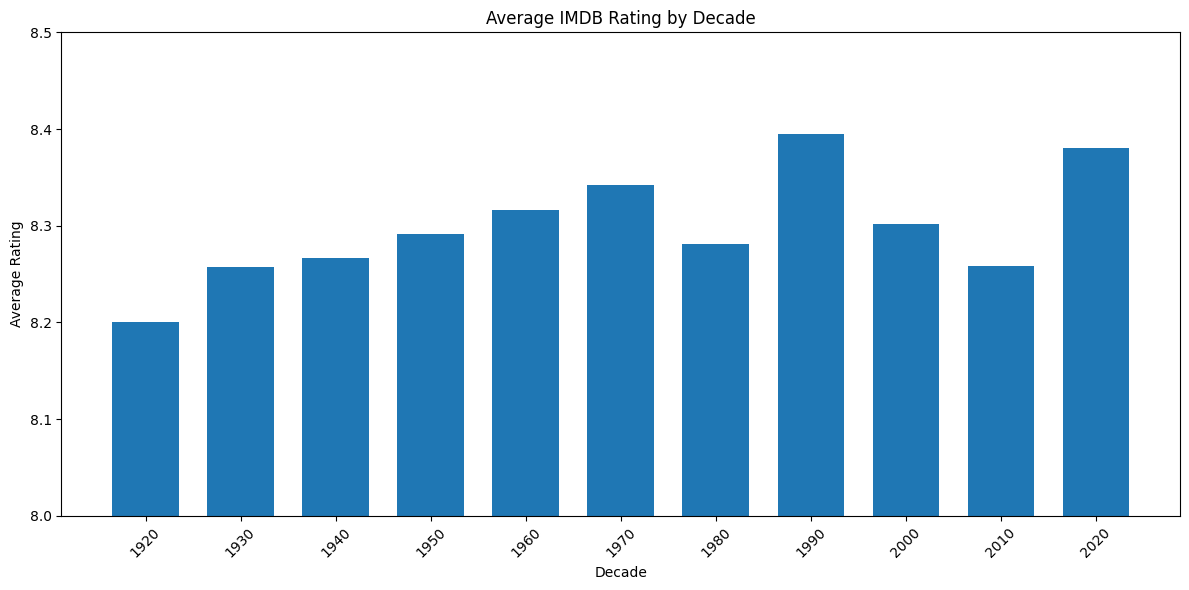

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart of average rating by the decade
plt.figure(figsize=(12, 6))
plt.bar(decade_ratings.index, decade_ratings.values, width=7)
plt.xlabel('Decade')
plt.ylabel('Average Rating')
plt.title('Average IMDB Rating by Decade')
plt.ylim(8.0, 8.5)
plt.xticks(decade_ratings.index, rotation=45)
plt.tight_layout()
plt.show()

PART C: For this graph, it shows the average IMDB rating of the top 250 films that are grouped by the decade that it was released in ranging from 1920s to the 2020s. Overall, the average ratings are stable across the decades even though the number of films from the decades varies (more or less) a lot. For the trend, the obvious one barley changed over time. Basically every decade falls within the average rating between 8.2 and 8.3. For example, the 1920s had the lowest average of 8.20 while the other decades such as 1930,1980,2000, and 2020 are all at 8.30.

A second trend is the uneven distributiion of films that is across all decades. The 1990s, 2000s, and 2010s, all together account for nearly more than half of the top 250 films, while the 1920s only contributes for 2 films and 6 for 1930s. This shows that the recent films dominates the top 250 list. To conclude, while the average rating of the Top 250 films are steady over the century, majority of it comes from the recent decades. A small number appears in the older film side, but most of it is in the recent realases.

PART A SUB QUESTION B

In [26]:
# Question 2/B: Do different content ratings have significantly different average IMDB ratings?
c_table = pd.pivot_table(df, values='rating', index='certificate', aggfunc=['mean', 'count', 'median', 'std'])
c_table.columns = ['Average Rating', 'Count', 'Median Rating', 'SD Rating']
c_table = c_table.sort_values(by='Average Rating', ascending=False)
c_table = c_table.round(2)


print(c_table)



             Average Rating  Count  Median Rating  SD Rating
certificate                                                 
PG-13                  8.36     36           8.25       0.28
R                      8.33     99           8.20       0.26
NC-17                  8.30      1           8.30        NaN
PG                     8.29     39           8.30       0.18
Not Rated              8.26     56           8.20       0.18
G                      8.24     19           8.20       0.16


PART B:

/tmp/ipykernel_1340/1501510091.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='certificate', y='rating', data=df, order=order, palette = 'Set1')


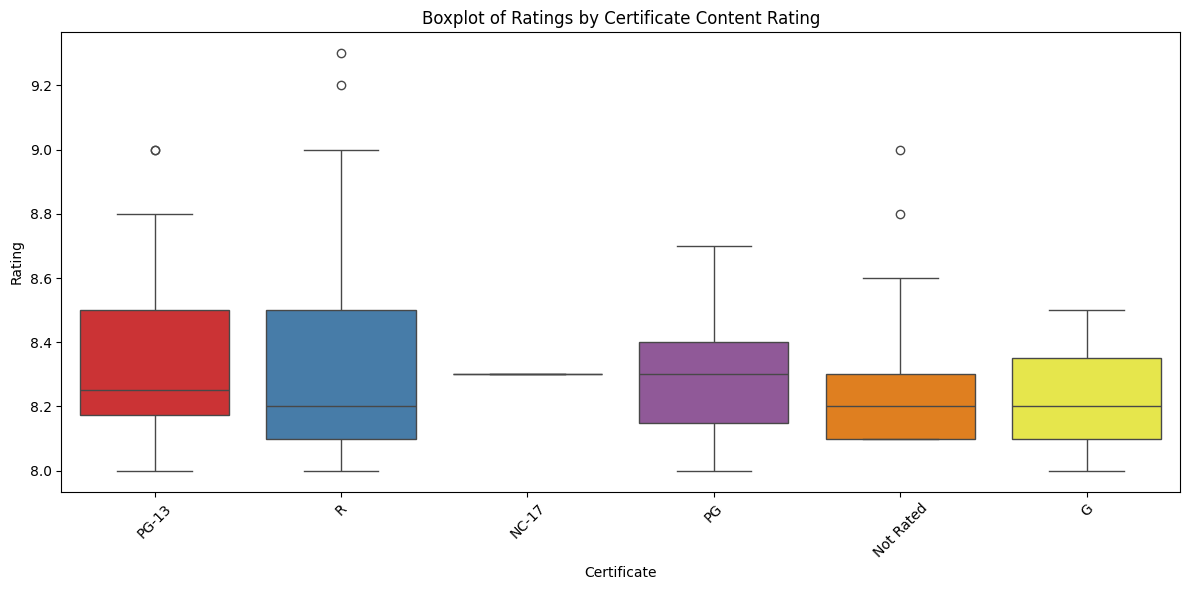

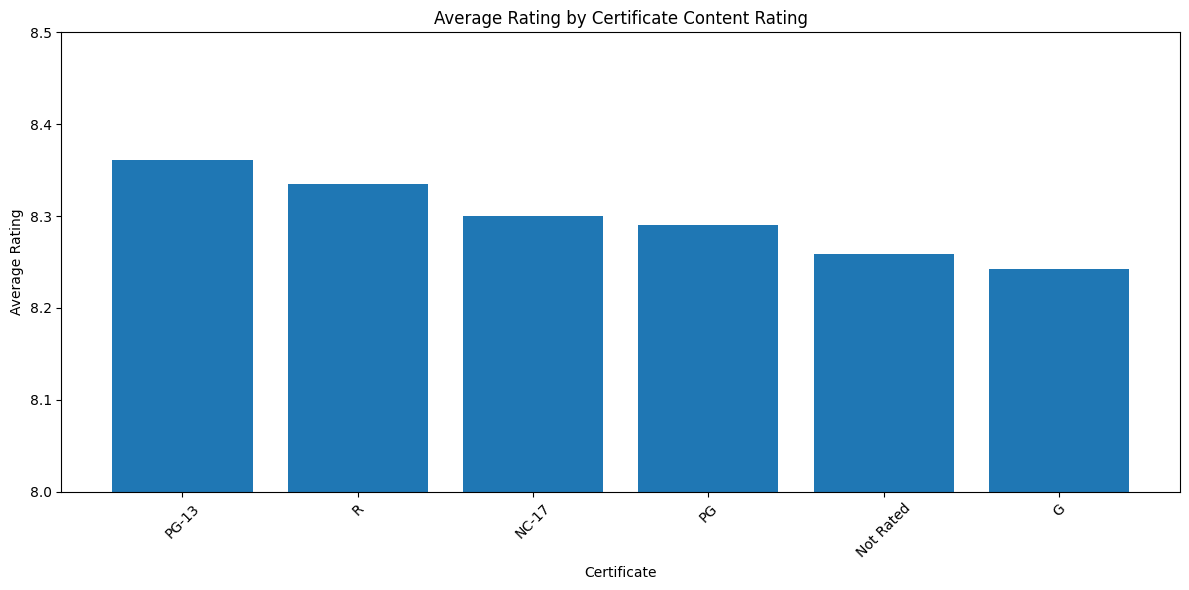

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# We will create a boxplot:
order = ['PG-13', 'R', 'NC-17', 'PG', 'Not Rated', 'G']
sns.boxplot(x='certificate', y='rating', data=df, order=order, palette = 'Set1')
plt.xlabel('Certificate')
plt.ylabel('Rating')
plt.title('Boxplot of Ratings by Certificate Content Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# BAR Chart for the mean data
plt.figure(figsize=(12, 6))
c_mean = df.groupby('certificate')['rating'].mean()
c_mean = c_mean.sort_values(ascending=False)
plt.bar(c_mean.index, c_mean.values)
plt.ylim(8.0, 8.5)
plt.xlabel('Certificate')
plt.ylabel('Average Rating')
plt.title('Average Rating by Certificate Content Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

PART C Interpretation: The graph above compares the distibution of the IMDB ratings across different content ratings, that includes PG-13, PG, G, and others. In this graph, the average ratinig is almost similar across all certificate categories, even though the number of films in each group are very different from each other. The most noticable trend is that content rating gives a little effect on the IMBD rating. The average ranges from about 8.29 to 8.31, while the R-rates ones are about lower than 8.29.

A second trend in this is the size per group. The rated R films dominate with 112 films and after that is the Not rated ones with 54, then PG-13 with 36. In difference to it, NC-17 only has one film making the average NOT reliable. To conclude, the content rating does not fully affect the IMDB ratings across the 250 films but the vast majority of the films falls between the R, PG, and PG-13 while a small number goes to the unrated side.

PART A QUESTION SUB C

In [28]:

#Question Sub C: Is there a relationship between movie runtime and ratings (IMDB)?

#Creating run-time bins:
df['runtime_bin'] = pd.cut(df['run_time'], bins=[0, 90, 120, 150, 180, float('inf')])
labels=['0-90 mins', '91-120 mins ', '121-150 mins', '151-180 mins', '181+']

#Pivot Table
runtime_table = pd.pivot_table(df, values='rating', index='runtime_bin', aggfunc=['mean', 'count'], observed=True)
runtime_table.columns = ['Average Rating', 'Count']
runtime_table = runtime_table.sort_values(by='Average Rating', ascending=False)
runtime_table = runtime_table.round(2)

print(runtime_table)







                Average Rating  Count
runtime_bin                          
(150.0, 180.0]            8.42     38
(180.0, inf]              8.41     14
(120.0, 150.0]            8.31     95
(0.0, 90.0]               8.26     19
(90.0, 120.0]             8.25     84


PART B:

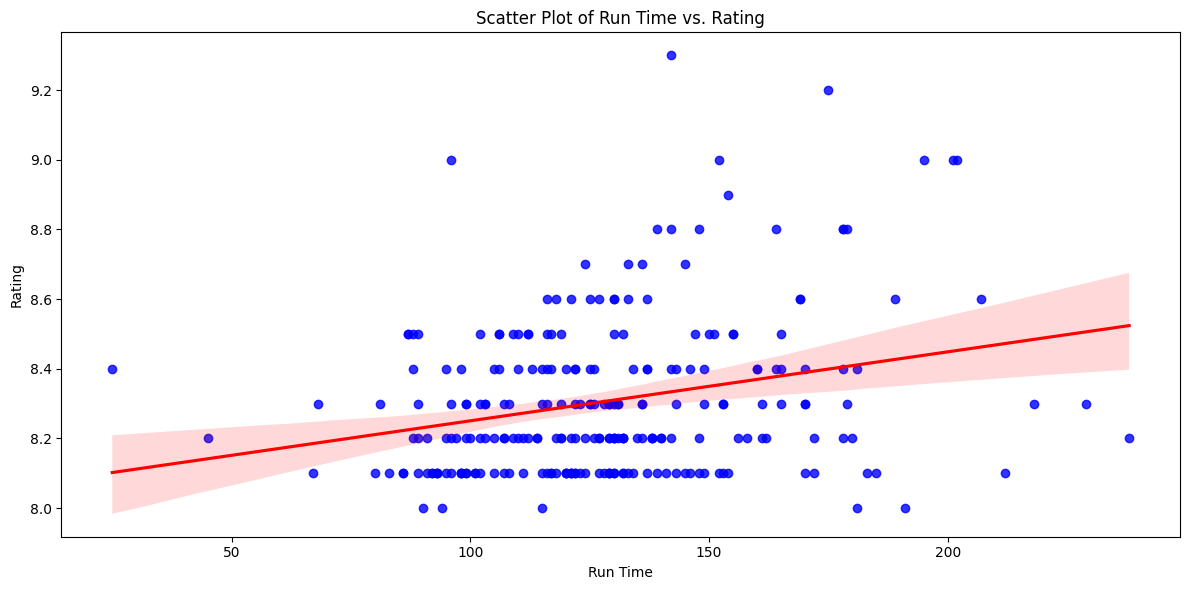

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
# Here we will create a scatter plot for this sub question
plt.figure(figsize=(12, 6))
sns.regplot(x='run_time', y='rating', data=df, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.xlabel('Run Time')
plt.ylabel('Rating')
plt.title('Scatter Plot of Run Time vs. Rating')
plt.tight_layout()
plt.show()

Part C Anaylsis: This graph, it shows the relationship between movie runtime and IMDB rating for the top 250 films. Overall, the longer scores that are a little higher than the shorter films. For Trend 1, the most noticeable difference trend is that the films in the range of 150-180 minutes have the best average rating of 8.42, and the 180 min range after that comes at a rating of 8.41. For the lower ends, the films that are under 120 mins have an average rating of 8.25 and the films in the 120-150 range are in the middle of the highest and lowest average with 8.31.

The second trend is the concentration of the films in the middle runtime. Majority of the films (179 of 250) all falls under the 120-150 minute and the 90-120. After that, only 14 films goes past the 180 minute mark. A small number of long films exist, but the majority cluster between 90-150 minutes. Wrap up this graph analysis, the longer films is shown to get slightly higher IMDB ratings, but the majority of the Top 250 fall between 90 and 150 minutes.


Summary: The main findings for this project were that the decade analysis revealed that the average ratings have remained stable for the past century. Every decade from the 1920s to the 2020s has a rating that falls between 8.20 and 8.30.. The way the films are spread out is not even. Most of the films come from the years. From the 1990s through the 2020s there are 150 films out of the 250. That means the later decades have way films, than the earlier ones. It’s a difference and it affects how the data looks.

The certificate comparison showed that content rating does not affect the ratings among the top 250 films. The average rating ranges from 8.29 to 8.31 across all the categories. R- rated films exceed the list with 112 films and NC-17 has only one film.

What I failed to find was that there was no strong trend in this analysis. All the ratings are tightly clustered because the dataset is set to have only high-rated films, which are all above 8.0, which limits variation. The relationship between the runtime and rating is weak and has little variance explained. To add on top, the dataset lacks streaming data nor the sales (digital) so it can’t show how viewing habits change in recent years.


I need to explore some things further. First I want to study the genre with the runtime and rating because this could show whether certain genres benefit more from longer runtimes. Second I plan to compare the directors and actors to find out if specific directors or actors consistently produce films. Third I will look at the relationship, between the release year and the genre to see whether audience preferences have shifted over time.


